# New England — Dataset Generation (demo)

End-to-end recipe for the 1,000-home synthetic dataset, demonstrated at 20 homes. Per home:

1. Draw (state, archetype, heating_fuel) from the RECS 2020 within-state joint distribution,
   with states weighted by RECS household weights.
2. Draw DER flags (has_pv, has_ev) from RECS state-level adoption shares.
3. Walk the 2018 calendar: month, dayofweek, and the home state's **real 2018 daily temp_bin
   trajectory** (GHCN) — so cold snaps and heat waves land on the right dates, coherently
   across homes in the same state.
4. Sample one 96-interval day per calendar day from the conditional GMM, decode,
   de-standardise.

The full-scale run (1,000 homes → ~35M rows, Parquet + CSV + metadata + dataset card) is the
P5 `generate-ne-dataset` deliverable.

In [1]:
import ast
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch

from opensynth.datasets.new_england import config
from opensynth.datasets.new_england.generate_dataset import load_model

torch.manual_seed(0)

DATA_DIR = Path("../../data")
MODEL_DIR = DATA_DIR / "models/new_england"
GMM_K = 200  # pick from the sweep {100, 200, 400}


def generate_matched(model, df_labels: pl.DataFrame) -> np.ndarray:
    """One synthetic day per row, batched over unique label combinations."""
    feats = list(config.FEATURE_COLS)
    out = np.empty((df_labels.height, 96), dtype=np.float32)
    pdf = df_labels.select(feats).to_pandas()
    for key, idx in pdf.groupby(feats).indices.items():
        labels = dict(zip(feats, (float(v) for v in key)))
        with torch.no_grad():
            sampled = model.sample_gmm_conditional(labels, len(idx))
        kwh = sampled["kwh"].numpy() * KWH_STD + KWH_MEAN
        if labels["has_pv"] == 0:
            # Net load may go negative only for PV homes (export)
            kwh = kwh.clip(min=0)
        out[idx] = kwh
    return out


model, meta = load_model(MODEL_DIR, GMM_K)
stats = pl.read_csv(DATA_DIR / "processed/new_england/train/mean_std.csv")
KWH_MEAN, KWH_STD = stats["mean"][0], stats["stdev"][0]
print("Model loaded. Features:", meta["feature_list"])
print(f"VAE final training loss: {meta['epoch_losses'][-1]:.3f}")


Model loaded. Features: ['state', 'archetype', 'heating_fuel', 'has_ev', 'has_pv', 'month', 'dayofweek', 'temp_bin']
VAE final training loss: 0.840


## Home labels from RECS

In [2]:
from opensynth.datasets.new_england.recs import (
    der_shares,
    joint_distribution,
    load_recs,
)

rng = np.random.default_rng(42)
N_HOMES = 20

df_recs = load_recs(DATA_DIR / "raw/new_england/recs/recs2020_public_v7.csv")
joint = joint_distribution(df_recs).to_pandas()
ders = der_shares(df_recs).to_pandas().set_index("state")
state_weights = (
    df_recs.group_by("state")
    .agg(pl.col("nweight").sum())
    .to_pandas()
    .set_index("state")["nweight"]
)
state_probs = state_weights / state_weights.sum()

homes = []
for i in range(N_HOMES):
    state = rng.choice(state_probs.index.to_numpy(), p=state_probs.to_numpy())
    cells = joint[joint["state"] == state]
    cell = cells.iloc[
        rng.choice(len(cells), p=cells["share"].to_numpy() / cells["share"].sum())
    ]
    homes.append(
        {
            "home_id": f"NE_{i:04d}",
            "state_postal": state,
            "state": config.STATE_ENCODING[state],
            "archetype": int(cell["archetype"]),
            "heating_fuel": int(cell["heating_fuel"]),
            "has_pv": int(rng.random() < ders.loc[state, "pv_share"]),
            "has_ev": int(rng.random() < ders.loc[state, "ev_share"]),
        }
    )
homes = pd.DataFrame(homes)
print(homes.groupby("state_postal").size())
homes.head(8)

state_postal
CT    5
MA    9
ME    1
NH    1
RI    1
VT    3
dtype: int64


,home_id,state_postal,state,archetype,heating_fuel,has_pv,has_ev
0,NE_0000,CT,0,0,2,0,0
1,NE_0001,VT,5,3,2,0,0
2,NE_0002,VT,5,0,3,0,0
3,NE_0003,MA,1,2,1,0,0
4,NE_0004,MA,1,0,1,0,0
5,NE_0005,MA,1,0,2,0,0
6,NE_0006,CT,0,0,1,0,0
7,NE_0007,RI,4,2,0,0,0


## 2018 calendar with real temperature trajectories

In [3]:
from opensynth.datasets.new_england.weather import build_temp_bin_table

temp_table = (
    build_temp_bin_table(str(DATA_DIR))
    .to_pandas()
    .rename(columns={"state": "state_postal"})
)
temp_table["date"] = pd.to_datetime(temp_table["date"])

calendar = homes.merge(
    temp_table[["state_postal", "date", "temp_bin"]], on="state_postal"
)
calendar["month"] = calendar["date"].dt.month
calendar["dayofweek"] = calendar["date"].dt.dayofweek
print(f"{len(calendar):,} home-days ({N_HOMES} homes)")
assert len(calendar) == N_HOMES * 365

7,300 home-days (20 homes)


## Generate and assemble

In [4]:
synth = generate_matched(model, pl.from_pandas(calendar[list(config.FEATURE_COLS)]))
calendar["daily_kwh"] = synth.sum(axis=1)

timestamps = (
    calendar["date"].values[:, None]
    + np.timedelta64(15, "m") * np.arange(96)[None, :]
)
df_long = pd.DataFrame(
    {
        "home_id": np.repeat(calendar["home_id"].to_numpy(), 96),
        "timestamp": timestamps.ravel(),
        "kwh": synth.ravel().astype(np.float32),
    }
)
print(f"{len(df_long):,} interval rows")
df_long.head(4)

700,800 interval rows


,home_id,timestamp,kwh
0,NE_0000,2018-01-01 00:00:00,0.147055
1,NE_0000,2018-01-01 00:15:00,0.150118
2,NE_0000,2018-01-01 00:30:00,0.151304
3,NE_0000,2018-01-01 00:45:00,0.146677


count       20.0
mean      7315.0
std       2110.0
min       4392.0
25%       6312.0
50%       6806.0
75%       7642.0
max      15097.0
Name: daily_kwh, dtype: float64


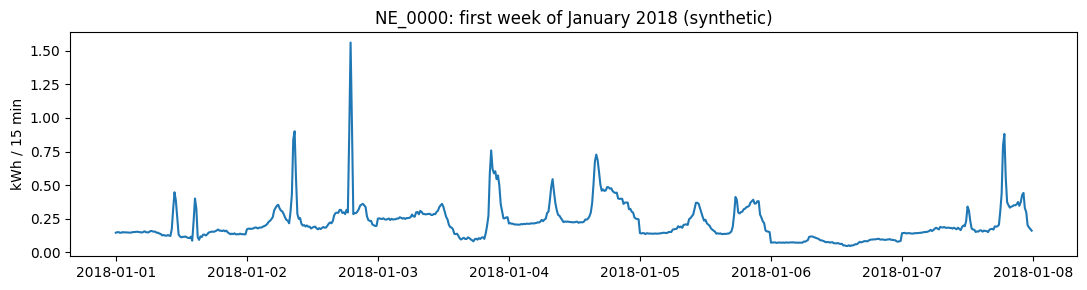

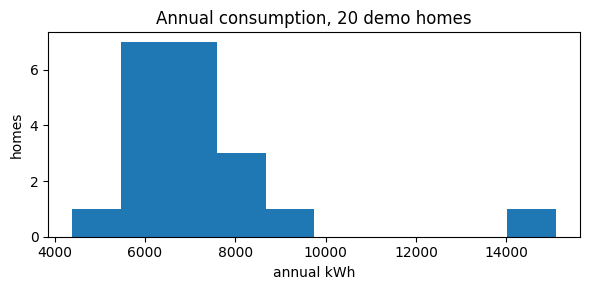

In [5]:
home0 = homes["home_id"].iloc[0]
week = df_long[
    (df_long["home_id"] == home0) & (df_long["timestamp"] < "2018-01-08")
]
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(week["timestamp"], week["kwh"])
ax.set_ylabel("kWh / 15 min")
ax.set_title(f"{home0}: first week of January 2018 (synthetic)")
plt.tight_layout()

annual = calendar.groupby("home_id")["daily_kwh"].sum()
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(annual, bins=10)
ax.set_xlabel("annual kWh")
ax.set_ylabel("homes")
ax.set_title(f"Annual consumption, {N_HOMES} demo homes")
plt.tight_layout()
print(annual.describe().round(0))

## Write the demo dataset

In [6]:
out_dir = DATA_DIR / "synthetic/new_england"
out_dir.mkdir(parents=True, exist_ok=True)
df_long.to_parquet(out_dir / "demo_20homes.parquet", index=False)
homes.to_csv(out_dir / "demo_20homes_metadata.csv", index=False)
print("Wrote", sorted(p.name for p in out_dir.iterdir()))

Wrote ['demo_20homes.parquet', 'demo_20homes_metadata.csv', 'generation_summary.json', 'ne_synthetic_1000homes.csv.gz', 'ne_synthetic_1000homes.parquet', 'ne_synthetic_1000homes_metadata.csv']


## Toward the full dataset

Still to fold in before the 1,000-home run:

- **PV / net-load convention**: in place — `has_pv` homes carry PVWatts-model generation
  (Open-Meteo 2018 shapes, PVGIS-NSRDB cross-check) netted out of both training data and
  synthetic output; net load goes negative during export.
- **EV training mix**: v1 is RECS-honest (0.6–1.7 % EV shares). If the EV signature proves too
  weak in evaluation, the documented alternative is oversampling EV homes in the training mix
  while keeping generation-time draws at RECS shares.
- Delivery: Parquet + CSV + metadata + `DATASET_CARD.md`, Zenodo upload, upstream PR. The
  card reports metrics in the fidelity / utility / privacy vocabulary of Chai et al. 2024
  (arXiv:2407.11785), reusing this repo's own evaluation tooling — see
  `ne_evaluation.ipynb`.